## Imports

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import json
import os 
from datetime import datetime 
from pathlib import Path

## Ingestão

In [2]:
df = pd.read_csv('data/incidents_master.csv')

In [3]:
df.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [5]:
df.isna().sum()

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

### metadados de ingestão

In [6]:
df['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')

## Conversão de tipos

In [7]:
# Datas
for col in ['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# created_at e updated_at têm fuso
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df['updated_at']  = pd.to_datetime(df['updated_at'],  utc=True, errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   incident_id               850 non-null    object             
 1   company_name              850 non-null    object             
 2   company_revenue_usd       850 non-null    float64            
 3   country_hq                850 non-null    object             
 4   industry_primary          850 non-null    object             
 5   industry_secondary        153 non-null    object             
 6   employee_count            850 non-null    int64              
 7   is_public_company         850 non-null    bool               
 8   stock_ticker              412 non-null    object             
 9   incident_date             850 non-null    datetime64[ns]     
 10  incident_date_estimated   850 non-null    bool               
 11  discovery_date     

## Persistência

In [9]:
Path('data/bronze').mkdir(parents=True, exist_ok=True)

df.to_parquet('./data/bronze/bronze.parquet')

In [10]:
#tamanho dataset original em bits
Path('data/incidents_master.csv').stat().st_size

438941

In [11]:
#tamanho da camada bronze em bits
Path('data/bronze/bronze.parquet').stat().st_size

132912

In [12]:
df_bronze = pd.read_parquet('./data/bronze/bronze.parquet')

### Verificando nulos

In [13]:
# Contagem e percentual de nulos por coluna

percent_nulos = df_bronze.isnull().mean() * 100

print(percent_nulos.round(2))

incident_id                  0.00
company_name                 0.00
company_revenue_usd          0.00
country_hq                   0.00
industry_primary             0.00
industry_secondary          82.00
employee_count               0.00
is_public_company            0.00
stock_ticker                51.53
incident_date                0.00
incident_date_estimated      0.00
discovery_date               0.00
disclosure_date              0.00
attack_vector_primary        0.00
attack_vector_secondary     75.18
attack_chain                32.35
attributed_group            43.29
attribution_confidence      43.29
data_compromised_records    29.18
data_type                   29.18
systems_affected             0.00
downtime_hours              50.59
data_source_primary          0.00
data_source_secondary       54.59
data_source_type             0.00
confidence_tier              0.00
quality_score                0.00
quality_grade                0.00
review_flag                 91.76
notes         

<Axes: >

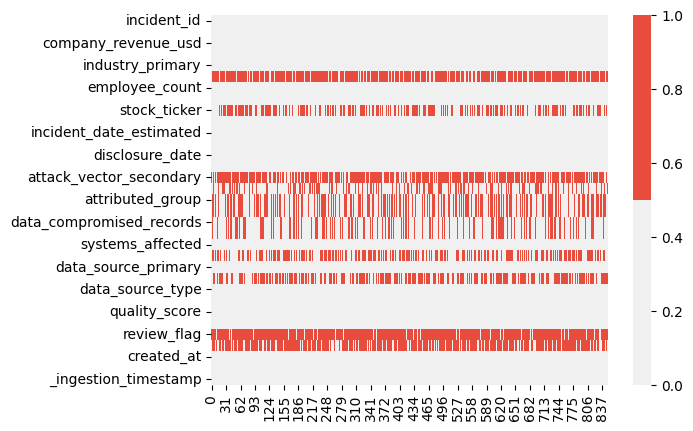

In [14]:
# Visualizacao do mapa de nulos
plt.Figure(figsize=(12,5))
sns.heatmap(df_bronze.isnull().T, cmap=['#F0F0F0','#E74C3C'])


## Buscando duplicatas

In [15]:
df_bronze[df_bronze.duplicated() == True]

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp


In [16]:
df_bronze.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,Multiple subsidiaries affected across 6 jurisd...,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-06
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-06
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-06
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,None,912,True,SFM,2021-03-15,...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-06
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,None,1662,True,SQI,2021-12-04,...,None,company_pr,2,79.82,Silver,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2026-04-06


In [17]:
df_bronze[df_bronze.duplicated(subset=['incident_id']) == True]


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp


## Metadados de Ingestão — Bronze

Registro completo de metadados conforme exigido no projeto: nome do arquivo, quantidade de linhas, hash SHA-256 e data/hora da carga.

In [18]:
import hashlib
from datetime import datetime
from pathlib import Path

arquivo = Path('data/incidents_master.csv')

# Hash SHA-256 do arquivo original
sha256 = hashlib.sha256(arquivo.read_bytes()).hexdigest()

metadata_bronze = {
    'arquivo': arquivo.name,
    'linhas': len(df),
    'colunas': len(df.columns),
    'tamanho_bytes': arquivo.stat().st_size,
    'hash_sha256': sha256,
    'data_carga': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'camada': 'bronze'
}

print(json.dumps(metadata_bronze, indent=2))

# Salvar metadados em JSON ao lado do parquet
Path('data/bronze').mkdir(parents=True, exist_ok=True)
with open('data/bronze/metadata_bronze.json', 'w') as f:
    json.dump(metadata_bronze, f, indent=2)

print('\nMetadados salvos em data/bronze/metadata_bronze.json')


{
  "arquivo": "incidents_master.csv",
  "linhas": 850,
  "colunas": 33,
  "tamanho_bytes": 438941,
  "hash_sha256": "9819d9ad6baeadca4c503d1146def6504da32e42b9e14e38b0008b24ffc84225",
  "data_carga": "2026-04-06 19:42:26",
  "camada": "bronze"
}

Metadados salvos em data/bronze/metadata_bronze.json


## Relatório de Qualidade dos Dados — Bronze

Verificação automática com regras claras para identificar falhas de qualidade.

In [19]:
def gerar_relatorio_qualidade(df, nome_camada='bronze'):
    relatorio = []
    total_linhas = len(df)

    for col in df.columns:
        nulos = df[col].isnull().sum()
        pct_nulo = nulos / total_linhas * 100
        duplicados = df[col].duplicated().sum() if df[col].dtype == 'object' else None
        status = 'OK'
        if pct_nulo > 50:
            status = 'CRITICO - >50% nulos'
        elif pct_nulo > 20:
            status = 'ATENCAO - >20% nulos'
        relatorio.append({
            'coluna': col,
            'tipo': str(df[col].dtype),
            'nulos': nulos,
            'pct_nulo': round(pct_nulo, 2),
            'status': status
        })

    df_rel = pd.DataFrame(relatorio)
    duplicatas_totais = df.duplicated().sum()
    print(f'=== Relatório de Qualidade — Camada {nome_camada.upper()} ===')
    print(f'Total de linhas : {total_linhas}')
    print(f'Linhas duplicadas: {duplicatas_totais}')
    print()
    print(df_rel[['coluna','tipo','nulos','pct_nulo','status']].to_string(index=False))
    return df_rel

df_qualidade = gerar_relatorio_qualidade(df_bronze, 'bronze')

# Salvar relatório como CSV
df_qualidade.to_csv('data/bronze/relatorio_qualidade_bronze.csv', index=False)
print('\nRelatório salvo em data/bronze/relatorio_qualidade_bronze.csv')


=== Relatório de Qualidade — Camada BRONZE ===
Total de linhas : 850
Linhas duplicadas: 0

                  coluna                tipo  nulos  pct_nulo               status
             incident_id              object      0      0.00                   OK
            company_name              object      0      0.00                   OK
     company_revenue_usd             float64      0      0.00                   OK
              country_hq              object      0      0.00                   OK
        industry_primary              object      0      0.00                   OK
      industry_secondary              object    697     82.00 CRITICO - >50% nulos
          employee_count               int64      0      0.00                   OK
       is_public_company                bool      0      0.00                   OK
            stock_ticker              object    438     51.53 CRITICO - >50% nulos
           incident_date      datetime64[ns]      0      0.00                  

# Silver

In [20]:
df_silver = df_bronze.copy()

### Ingestão 

# Limpeza, Tratamento de Datas e Padronização

### Removendo linhas totalmente duplicadas

In [21]:
df_silver = df_silver.drop_duplicates()

### Padronizando colunas categóricas

In [22]:
colunas_categoricas = ['attack_vector_primary', 'attack_vector_secondary', 'country_hq', 'data_type', 'attribution_confidence']
for col in colunas_categoricas:
    df_silver[col] = df_silver[col].str.lower().str.strip()

### Preenchendo valores vazios em colunas secundárias de ataque e grupo com 'desconhecido'

In [23]:
df_silver['attack_vector_secondary'] = df_silver['attack_vector_secondary'].fillna('desconhecido')
df_silver['attributed_group'] = df_silver['attributed_group'].fillna('desconhecido')
df_silver['stock_ticker'] = df_silver['stock_ticker'].fillna('nao_capital_aberto')

### Preenchendo nulos em colunas numéricas com 0 (ex: empresas que não tiveram horas de inatividade)

In [24]:
df_silver['downtime_hours'] = df_silver['downtime_hours'].fillna(0)
df_silver['data_compromised_records'] = df_silver['data_compromised_records'].fillna(0)

### Remoção de colunas com risco de Data Leakage


In [25]:
colunas_leakage = ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']

df_silver = df_silver.drop(columns=colunas_leakage)

print(f"Colunas removidas: {colunas_leakage}")
print(f"Shape após remoção: {df_silver.shape}")

Colunas removidas: ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']
Shape após remoção: (850, 29)


### Criação do Label para Machine Learning


In [26]:
df_silver['_is_high_impact'] = (
    (df_silver['data_compromised_records'] > 100_000) |
    (df_silver['downtime_hours'] > 72)
).astype(int)

print("Distribuição do label:")
print(df_silver['_is_high_impact'].value_counts())
print(f"\nProporção de alto impacto: {df_silver['_is_high_impact'].mean():.2%}")

Distribuição do label:
_is_high_impact
0    479
1    371
Name: count, dtype: int64

Proporção de alto impacto: 43.65%


### Salvando a Camada Silver


In [27]:
Path('data/silver').mkdir(parents=True, exist_ok=True)
df_silver.to_parquet('./data/silver/silver.parquet', index=False)

print(f"Silver salvo com sucesso!")
print(f"Shape final: {df_silver.shape}")
print(f"Tamanho do arquivo: {Path('data/silver/silver.parquet').stat().st_size} bytes")

Silver salvo com sucesso!
Shape final: (850, 30)
Tamanho do arquivo: 126994 bytes


## Documentação das Transformações — Silver

Registro de todas as transformações aplicadas sobre a camada Bronze para rastreabilidade.

In [28]:
transformacoes = [
    {'etapa': '1', 'acao': 'Remocao de duplicatas',         'detalhes': 'drop_duplicates() — linhas 100% identicas removidas'},
    {'etapa': '2', 'acao': 'Conversao de tipos de data',    'detalhes': 'incident_date, discovery_date, disclosure_date, created_at, updated_at -> datetime'},
    {'etapa': '3', 'acao': 'Padronizacao de categorias',    'detalhes': 'lower().strip() em: attack_vector_primary/secondary, country_hq, data_type, attribution_confidence'},
    {'etapa': '4', 'acao': 'Preenchimento de nulos',        'detalhes': 'attack_vector_secondary, attributed_group -> desconhecido; stock_ticker -> nao_capital_aberto; downtime_hours, data_compromised_records -> 0'},
    {'etapa': '5', 'acao': 'Remocao anti-leakage',          'detalhes': 'Removidas: quality_score, quality_grade, confidence_tier, review_flag'},
    {'etapa': '6', 'acao': 'Criacao do label ML',           'detalhes': 'is_high_impact=1 se data_compromised_records>100k OU downtime_hours>72'},
]

df_trans = pd.DataFrame(transformacoes)
print(df_trans.to_string(index=False))

# Salvar documentacao
df_trans.to_csv('data/silver/documentacao_transformacoes.csv', index=False)
print('\nDocumentacao salva em data/silver/documentacao_transformacoes.csv')


etapa                       acao                                                                                                                                     detalhes
    1      Remocao de duplicatas                                                                                          drop_duplicates() — linhas 100% identicas removidas
    2 Conversao de tipos de data                                                           incident_date, discovery_date, disclosure_date, created_at, updated_at -> datetime
    3 Padronizacao de categorias                                           lower().strip() em: attack_vector_primary/secondary, country_hq, data_type, attribution_confidence
    4     Preenchimento de nulos attack_vector_secondary, attributed_group -> desconhecido; stock_ticker -> nao_capital_aberto; downtime_hours, data_compromised_records -> 0
    5       Remocao anti-leakage                                                                        Removidas: quality_score, 

## Tabela Checklist Anti-Leakage

Documentação de cada coluna analisada quanto ao risco de data leakage para modelos preditivos.

In [29]:
checklist_leakage = [
    {'coluna': 'quality_score',      'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Score calculado apos o incidente — vaza informacao do futuro'},
    {'coluna': 'quality_grade',      'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Grade derivada do quality_score — mesmo problema'},
    {'coluna': 'confidence_tier',    'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Tier de confianca atribuido pos-analise — leakage temporal'},
    {'coluna': 'review_flag',        'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Flag de revisao manual — informacao nao disponivel no momento do incidente'},
    {'coluna': 'disclosure_date',    'risco': 'MEDIO', 'acao': 'MANTIDA',   'justificativa': 'Data de divulgacao publica — usar apenas como feature temporal, nao como proxy do target'},
    {'coluna': 'attribution_confidence','risco': 'BAIXO','acao': 'MANTIDA', 'justificativa': 'Confianca de atribuicao — pode ser desconhecida no momento; tratada como categorica'},
    {'coluna': 'data_compromised_records','risco':'MEDIO','acao':'MANTIDA - USADA NO LABEL', 'justificativa': 'Usada para definir o label is_high_impact; nao deve ser feature do modelo'},
    {'coluna': 'downtime_hours',     'risco': 'MEDIO', 'acao': 'MANTIDA - USADA NO LABEL', 'justificativa': 'Idem — compoe o label; excluir das features de treinamento'},
    {'coluna': 'is_high_impact',     'risco': 'N/A',   'acao': 'LABEL',     'justificativa': 'Variavel alvo criada para ML'},
]

df_leakage = pd.DataFrame(checklist_leakage)
print(df_leakage.to_string(index=False))

# Salvar checklist
df_leakage.to_csv('data/silver/checklist_anti_leakage.csv', index=False)
print('\nChecklist salvo em data/silver/checklist_anti_leakage.csv')


                  coluna risco                     acao                                                                            justificativa
           quality_score  ALTO                 REMOVIDA                             Score calculado apos o incidente — vaza informacao do futuro
           quality_grade  ALTO                 REMOVIDA                                         Grade derivada do quality_score — mesmo problema
         confidence_tier  ALTO                 REMOVIDA                               Tier de confianca atribuido pos-analise — leakage temporal
             review_flag  ALTO                 REMOVIDA               Flag de revisao manual — informacao nao disponivel no momento do incidente
         disclosure_date MEDIO                  MANTIDA Data de divulgacao publica — usar apenas como feature temporal, nao como proxy do target
  attribution_confidence BAIXO                  MANTIDA      Confianca de atribuicao — pode ser desconhecida no momento; tratada c

# 

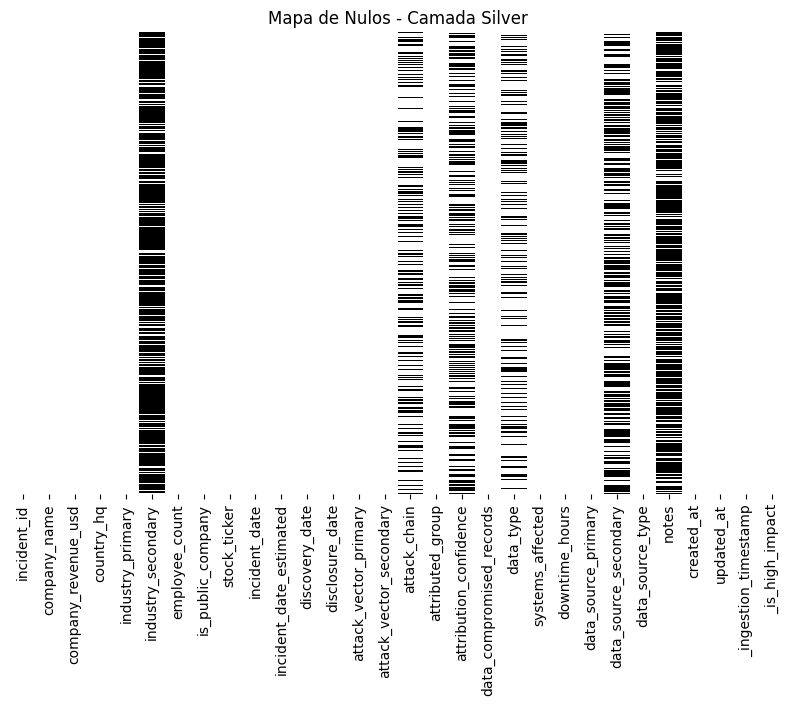

In [30]:
plt.figure(figsize=(10, 6))

sns.heatmap(df_silver.isnull(), yticklabels=False, cbar=False, cmap='Greys')

plt.title('Mapa de Nulos - Camada Silver')
plt.show()

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_4092\1912410602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')


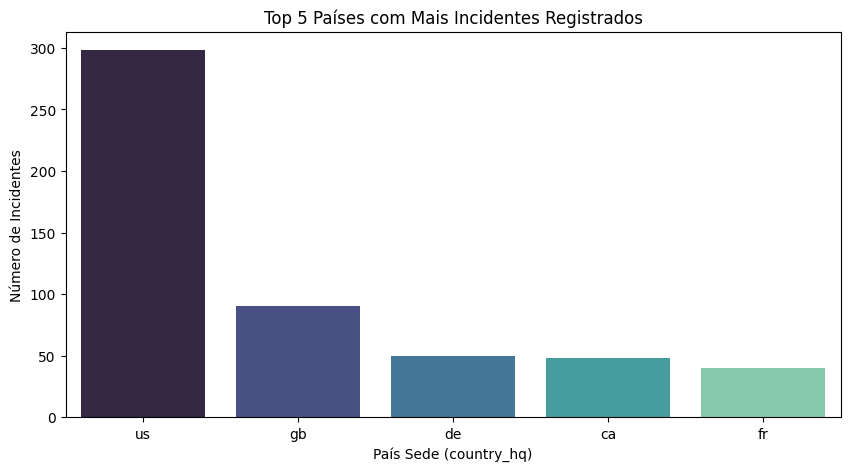

In [31]:
plt.figure(figsize=(10, 5))

top_paises = df_silver['country_hq'].value_counts().head(5)

sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')

plt.title('Top 5 Países com Mais Incidentes Registrados')
plt.xlabel('País Sede (country_hq)')
plt.ylabel('Número de Incidentes')

plt.show()

## Análise Exploratória — Gráfico 1: Distribuição dos Vetores de Ataque por Impacto

Comparação da proporção de incidentes de alto impacto para cada tipo de vetor de ataque primário.

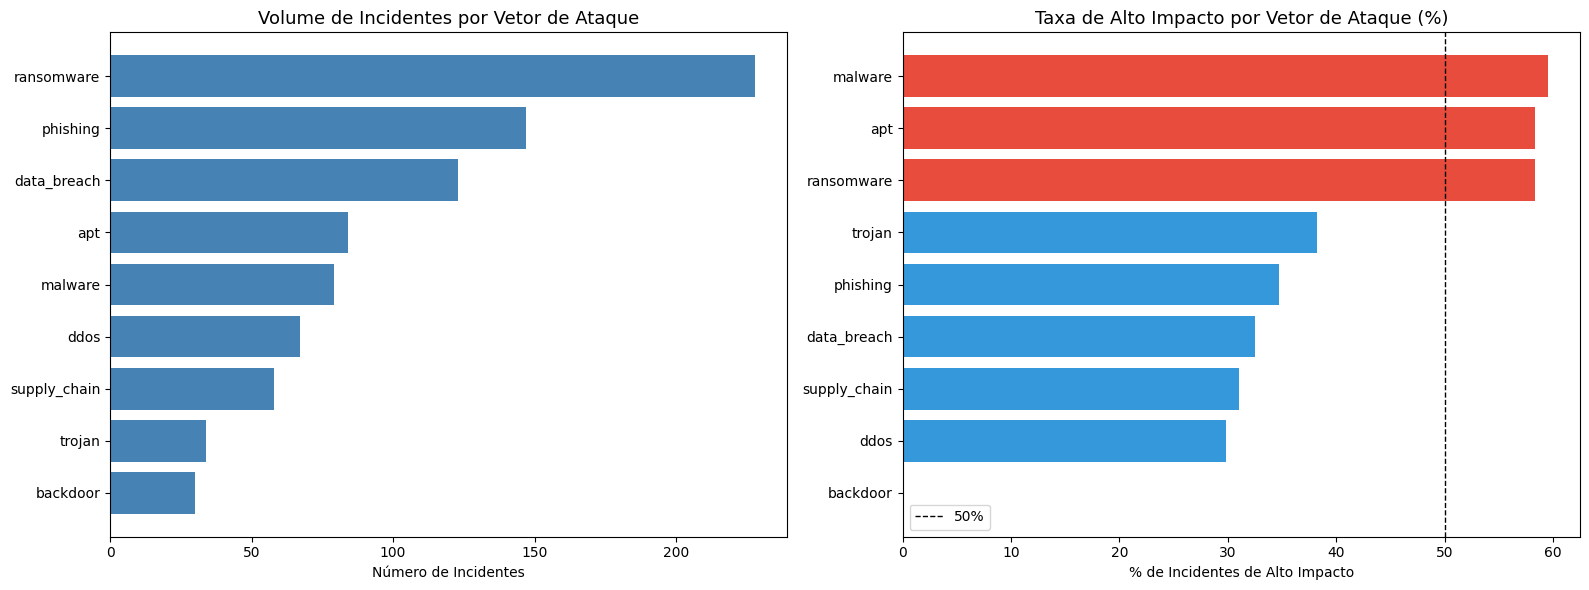

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contagem total por vetor
contagem_vetor = df_silver['attack_vector_primary'].value_counts()
axes[0].barh(contagem_vetor.index, contagem_vetor.values, color='steelblue')
axes[0].set_title('Volume de Incidentes por Vetor de Ataque', fontsize=13)
axes[0].set_xlabel('Número de Incidentes')
axes[0].invert_yaxis()

# Taxa de alto impacto por vetor
taxa_impacto = df_silver.groupby('attack_vector_primary')['_is_high_impact'].mean().sort_values(ascending=False)
cores = ['#e74c3c' if v > 0.5 else '#3498db' for v in taxa_impacto.values]
axes[1].barh(taxa_impacto.index, taxa_impacto.values * 100, color=cores)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
axes[1].set_title('Taxa de Alto Impacto por Vetor de Ataque (%)', fontsize=13)
axes[1].set_xlabel('% de Incidentes de Alto Impacto')
axes[1].legend()
axes[1].invert_yaxis()
plt.tight_layout()



## Análise Exploratória — Gráfico 2: Evolução Temporal dos Incidentes (2021–2025)

Série temporal mostrando o volume de incidentes por trimestre, separando alto e baixo impacto.

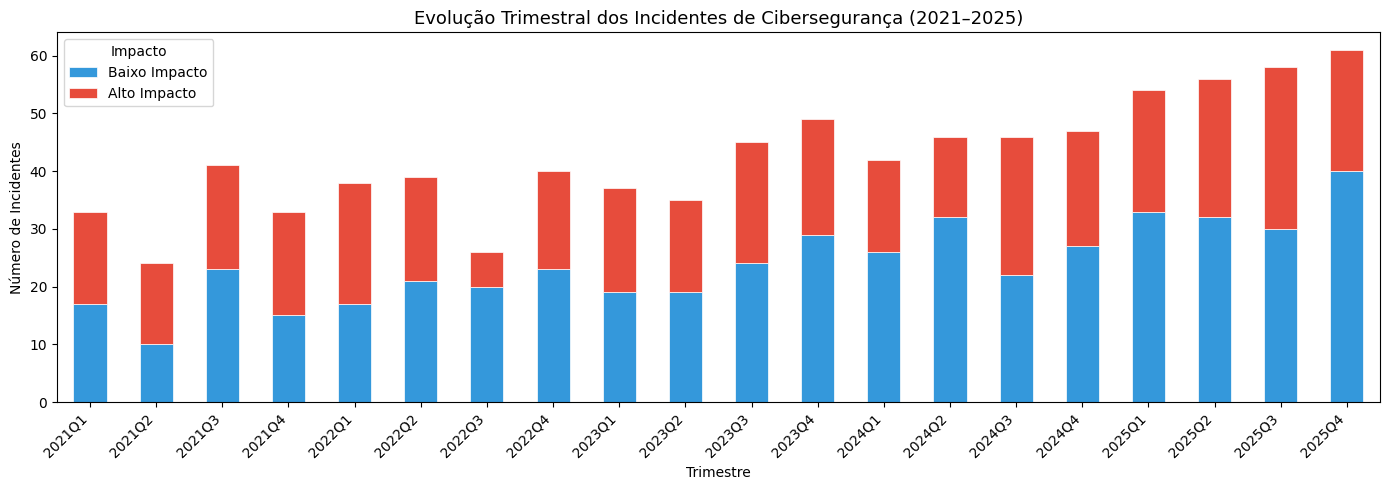

In [33]:
df_temp = df_silver.copy()
df_temp['trimestre'] = df_temp['incident_date'].dt.to_period('Q').astype(str)

evolucao = df_temp.groupby(['trimestre', '_is_high_impact']).size().unstack(fill_value=0)
evolucao.columns = ['Baixo Impacto', 'Alto Impacto']

fig, ax = plt.subplots(figsize=(14, 5))
evolucao.plot(kind='bar', stacked=True, ax=ax,
              color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=0.5)

ax.set_title('Evolução Trimestral dos Incidentes de Cibersegurança (2021–2025)', fontsize=13)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de Incidentes')
ax.legend(title='Impacto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()



## Análise Exploratória — Gráfico 3: Top 10 Países × Vetor de Ataque

Heatmap cruzando os 10 países com mais incidentes contra os vetores de ataque mais frequentes.

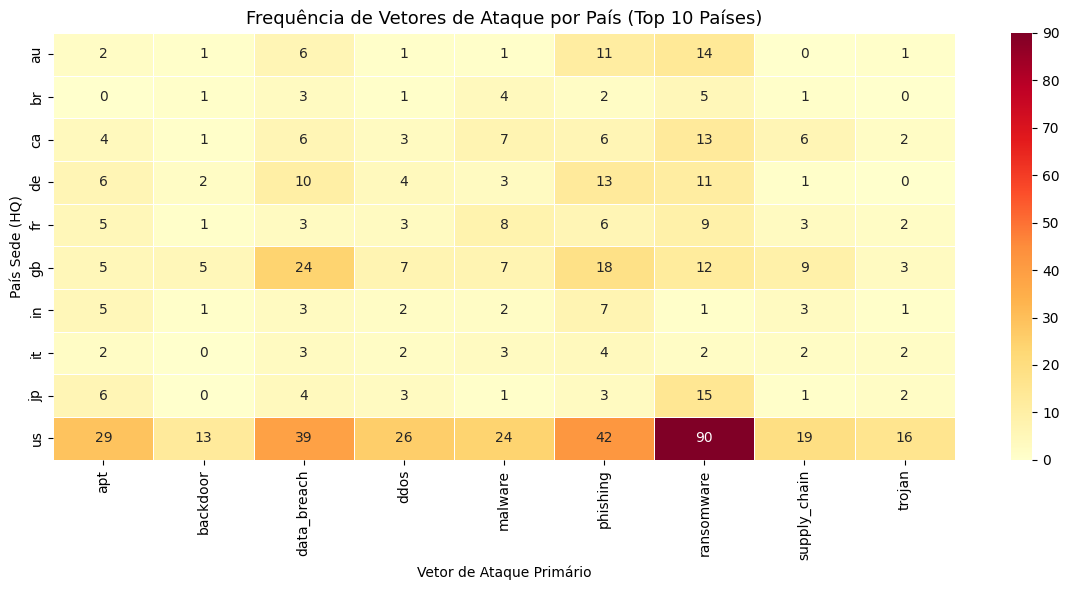

In [34]:
top_paises = df_silver['country_hq'].value_counts().head(10).index
df_hm = df_silver[df_silver['country_hq'].isin(top_paises)]

pivot = df_hm.pivot_table(index='country_hq', columns='attack_vector_primary',
                           values='incident_id', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Frequência de Vetores de Ataque por País (Top 10 Países)', fontsize=13)
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('País Sede (HQ)')
plt.tight_layout()
plt.show()


## Data Lineage do Pipeline

Representação textual do fluxo de dados desde a origem até a camada Prata, conforme solicitado no projeto.

In [35]:
lineage = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                        DATA LINEAGE — PIPELINE MEDALION                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [ORIGEM]                                                                    ║
║  data/incidents_master.csv                                                   ║
║  • Formato: CSV bruto                                                        ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA BRONZE                                   │     ║
║  │  data/bronze/bronze.parquet                                         │     ║
║  │  Transformações:                                                    │     ║
║  │  ✔ Padronização de nomes de colunas (snake_case)                    │     ║
║  │  ✔ Conversão de tipos básicos (datas, numéricos)                    │     ║
║  │  ✔ Adição de _ingestion_timestamp                                   │     ║
║  │  ✔ Registro de metadados (hash SHA-256, tamanho, linhas)            │     ║
║  │  ✔ Relatório de qualidade gerado (nulos, duplicatas)                │     ║
║  └─────────────────────────────────────────────────────────────────────┘     ║
║                          │                                                   ║
║              ┌───────────┴─────────────┐                                    ║
║              │   VALIDAÇÕES APLICADAS  │                                    ║
║              │  • % nulos por coluna   │                                    ║
║              │  • Detecção duplicatas  │                                    ║
║              │  • Checagem de datas    │                                    ║
║              └───────────┬─────────────┘                                    ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA SILVER                                   │     ║
║  │  data/silver/silver.parquet                                         │     ║
║  │  Transformações:                                                    │     ║
║  │  ✔ Remoção de duplicatas totais                                     │     ║
║  │  ✔ Conversão/validação de colunas de data                           │     ║
║  │  ✔ Padronização de categorias (lower/strip)                        │     ║
║  │  ✔ Preenchimento de nulos com valores semânticos                   │     ║
║  │  ✔ Remoção de colunas com data leakage (4 colunas)                 │     ║
║  │  ✔ Criação do label '_is_high_impact' para ML                       │     ║
║  │  Colunas removidas: quality_score, quality_grade,                   │     ║
║  │                     confidence_tier, review_flag                    │     ║
║  └─────────────────────────────────────────────────────────────────────┘     ║
║                          │                                                   ║
║                          ▼                                                   ║
║  [DESTINO FINAL]                                                             ║
║  Dataset pronto para uso em modelos de Machine Learning                      ║
║  Target: is_high_impact (classificação binária)                              ║
║  Shape final: 850 linhas × 30 colunas                                        ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(lineage)



╔══════════════════════════════════════════════════════════════════════════════╗
║                        DATA LINEAGE — PIPELINE MEDALION                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [ORIGEM]                                                                    ║
║  data/incidents_master.csv                                                   ║
║  • Formato: CSV bruto                                                        ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA BRONZE                                   │     ║
║  │  data/bronze/bronze.parquet                                         │     ║
║  │  Transformações:        